In [22]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
import sys
import os

sys.path.append(os.path.abspath("/Users/imanemokhtatif/Desktop/REMOTEChlamy_Project_v2-main"))

In [25]:
from Scripts_Imane import Plots
import pandas as pd 
from Scripts_Imane import gene_self_sim
from scipy.stats import norm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from collections import defaultdict
from sklearn.impute import SimpleImputer
from inmoose.pycombat import pycombat_norm, pycombat_seq

In [13]:
#data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_04_clean.csv')
old = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase1.csv')
new = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_05_claireNorm_PHASE2_mutants&WT_with_slopes.csv')

/tmp/ipykernel_3706705/1488361597.py:3: DtypeWarning: Columns (463,464) have mixed types. Specify dtype option on import or set low_memory=False.
  new = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_05_claireNorm_PHASE2_mutants&WT_with_slopes.csv')


### Raw slopes (over the whole time serie without separating light and dark)

In [5]:
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/bayesian_phase2_time_series.csv')
#data = data[data['start_date']>= '2024-05-19']
y2_columns = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col]
data[y2_columns] = data[y2_columns].apply(pd.to_numeric, errors='coerce')
elapsed_hours = np.array([float(col.split('_')[-1]) for col in y2_columns]).reshape(-1, 1)
data['y2_overall_slope'] = np.nan
for idx, row in data.iterrows():
    y2_values = row[y2_columns].values.astype(float)
    valid_indices = ~np.isnan(y2_values)
    y2_values_valid = y2_values[valid_indices]
    elapsed_hours_valid = elapsed_hours[valid_indices]
    if len(y2_values_valid) > 1:
        model = LinearRegression()
        model.fit(elapsed_hours_valid.reshape(-1, 1), y2_values_valid.reshape(-1, 1))
        data.loc[idx, 'y2_overall_slope'] = model.coef_[0][0]
data.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/bayesian_phase2_time_series.csv', index=False)

### Normalised y2 by the mean of all the WTs then compute overall slope

In [ ]:
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2.csv')
data = data[data['start_date'] >= '2024-05-19']
data = data[data['plate'].astype(str).str.startswith('3')]
y2_columns = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col]
data[y2_columns] = data[y2_columns].apply(pd.to_numeric, errors='coerce')
elapsed_hours = np.array([float(col.split('_')[-1]) for col in y2_columns]).reshape(-1, 1)
data['y2_slope'] = np.nan
for (plate, regime), group in data.groupby(['plate', 'light_regime']):
    wt_subset = group[group['mutant_ID'].isin(['WT', 'WT CLiP'])]
    if wt_subset.empty:
        continue
    mean_ts = wt_subset[y2_columns].mean()
    for idx, row in group.iterrows():
        y2_values = row[y2_columns].values.astype(float)
        if (row['mutant_ID']!='WT'):
            y2_values = y2_values - mean_ts.values
        valid = ~np.isnan(y2_values)
        y2_valid = y2_values[valid]
        time_valid = elapsed_hours[valid]
        if len(y2_valid) > 1:
            model = LinearRegression()
            model.fit(time_valid.reshape(-1, 1), y2_valid.reshape(-1, 1))
            slope = model.coef_[0][0]
            data.loc[idx, 'y2_slope'] = slope
            data.loc[idx, y2_columns] = y2_values
data.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase2_05_WTmeanTSsubtracted.csv', index=False)

### Demean the slopes themselves (not the y2), same result because of linearity

In [12]:
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase2_05_RAWslopes.csv')
data = data[data['plate'].astype(str).str.startswith('3')]
data['y2_slope_norm'] = np.nan
for (plate, regime), group in data.groupby(['plate', 'light_regime']):
    wt_slopes = group[group['mutant_ID'].isin(['WT', 'WT CLiP'])]['y2_slope'].dropna()
    if wt_slopes.empty:
        continue
    wt_mean_slope = wt_slopes.mean()
    data.loc[group.index, 'y2_slope_norm'] = group['y2_slope'] - wt_mean_slope
data.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase2_05_rawslopes_Slopesdemeaned.csv', index=False)

/tmp/ipykernel_2377950/65000887.py:1: DtypeWarning: Columns (1,366,367,368,369,462,463) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase2_05_RAWslopes.csv')


### Z-scores of the slopes (demean and std)

In [10]:
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase2_05_RAWslopes.csv')
data['y2_slope_z'] = np.nan
for (plate, regime), group in data.groupby(['plate', 'light_regime']):
    wt_slopes = group['y2_slope'].dropna()#[group['mutant_ID'].isin(['WT', 'WT CLiP'])]
    all_slopes = group['y2_slope'].dropna()
    if wt_slopes.empty:
        continue
    mu  = wt_slopes.mean()
    std = wt_slopes.std(ddof=0)     
    if std == 0:
        z = group['y2_slope'] - mu
    else:
        z = (group['y2_slope'] - mu) / std
    data.loc[group.index, 'y2_slope_z'] = z
data.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase2_05_RAWslopes_zscore_meanstdofallmutants.csv', index=False)

/tmp/ipykernel_2754922/3212439080.py:1: DtypeWarning: Columns (1,366,367,368,369,462,463) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase2_05_RAWslopes.csv')


### Mixed effects to detrend slopes

In [ ]:
import pandas as pd

data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase2_05_RAWslopes.csv')

data = data[~data['mutant_ID'].isin(['WT', 'WT CLiP'])]

data = data.dropna(subset=['y2_slope', 'plate', 'light_regime'])

data['plate'] = data['plate'].astype(str)
data['light_regime'] = data['light_regime'].astype(str)
import statsmodels.formula.api as smf

# fixed effect light_regime, random effect intercept par plate
model = smf.mixedlm("y2_slope ~ light_regime", data, groups=data["plate"])
result = model.fit()
print(result.summary())
data['slope_detrended'] = result.resid


/tmp/ipykernel_2377950/4248556654.py:3: DtypeWarning: Columns (1,366,367,368,369,462,463) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase2_05_RAWslopes.csv')
/home/imokhtatif/miniconda3/envs/myenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/imokhtatif/miniconda3/envs/myenv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


                Mixed Linear Model Regression Results
Model:                 MixedLM     Dependent Variable:     y2_slope   
No. Observations:      39370       Method:                 REML       
No. Groups:            12          Scale:                  0.0000     
Min. group size:       2632        Log-Likelihood:         244858.1058
Max. group size:       3511        Converged:              Yes        
Mean group size:       3280.8                                         
----------------------------------------------------------------------
                          Coef.  Std.Err.    z     P>|z| [0.025 0.975]
----------------------------------------------------------------------
Intercept                 -0.000    0.000   -8.346 0.000 -0.000 -0.000
light_regime[T.1min-1min]  0.000    0.000    5.025 0.000  0.000  0.000
light_regime[T.1min-5min]  0.000    0.000   17.084 0.000  0.000  0.000
light_regime[T.20h_HL]    -0.002    0.000 -226.543 0.000 -0.002 -0.002
light_regime[T.20h_ML] 

/home/imokhtatif/miniconda3/envs/myenv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/imokhtatif/miniconda3/envs/myenv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [ ]:
#### R computed fitted slope
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/fitted_slopes_per_sample.csv')

"""
data$light_regime <- as.factor(data$light_regime)
data$plate <- as.factor(data$plate)
model <- lmer(y2_slope ~ light_regime + (1 + light_regime | plate), data = data)
"""


## Combat to debatch

In [ ]:
######### dummy data
from combat.pycombat import pycombat
import pandas as pd
import matplotlib.pyplot as plt

# the datasets are dataframes where:
    # the indexes correspond to the gene names
    # the column names correspond to the sample names
# Any number (>=2) of datasets can be treated
dataset_1 = pd.read_pickle("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/combat_essai/GSE18520.pickle") # datasets can also be stored in csv, tsv, etc files
dataset_2 = pd.read_pickle("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/combat_essai/GSE66957.pickle")
dataset_3 = pd.read_pickle("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/combat_essai/GSE69428.pickle")
data  =  pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase2_05_RAWslopes.csv')

# merge all the datasets into one, by keeping the common genes only
df_expression = pd.concat([dataset_1,dataset_2,dataset_3],join="inner",axis=1)

plt.boxplot(df_expression)
plt.show()

batch = []
datasets = [dataset_1,dataset_2,dataset_3]
for j in range(len(datasets)):
    batch.extend([j for _ in range(len(datasets[j].columns))])
batch = []
datasets = [dataset_1,dataset_2,dataset_3]
for j in range(len(datasets)):
    batch.extend([j for _ in range(len(datasets[j].columns))])

df_corrected = pycombat(df_expression,batch)

plt.boxplot(df_corrected)
plt.show()

need to format the data so as to, for the 20h_HL have one dataset per plate concatenated x wise, with the mutants as columns, and the y2_slopes as values for the different mutated_genes (mutated_genes as rows)

In [ ]:
#data  =  pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase2_05_RAWslopes.csv')
big_plates = ['30','31','32','33']
lights = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']

for light in lights : 
    for big_plate in big_plates:
        data  =  pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase2_05_RAWslopes.csv')
        data = data[data['light_regime'] == light]
        data = data[data['plate'].astype(str).str.startswith(big_plate)]
        data['mutant_unique'] = (
            data['mutant_ID'].astype(str) + '_' +
            data['well_id'].astype(str) + '_' +
            data['plate'].astype(str)
        )
        batch=[]
        grouped = data.groupby('plate')
        all_dfs = []
        for plate, group in grouped:
            group = group[['mutant_ID', 'mutated_genes', 'y2_slope']]
            group = group.pivot_table(index='mutated_genes',columns='mutant_ID', values='y2_slope')#, aggfunc='mean')
            #group.to_csv(f'/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/combat_plates_{big_plate}/phase2_05_RAWslopes_{light}_{plate}.csv')

        #folder = f'/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/combat_plates_{big_plate}'
        #all_dfs = []
        #batch = []

        #for fname in os.listdir(folder):
            #if (light in fname):#.endswith(f"{light}_{plate}.csv"):
                # df = pd.read_csv(os.path.join(folder, fname), index_col=0)
                # plate_id = fname.split("_")[-1].replace(".csv", "")
                # all_dfs.append(df)
                # batch.extend([plate_id] * df.shape[1])
                # print(batch)
            all_dfs.append(group)
            batch.extend([plate] * group.shape[1])
            print(batch)

        df_expression = pd.concat(all_dfs, axis=1, join="inner")
        na_cols = df_expression.columns[df_expression.isna().all()]
        batch = [b for i, b in enumerate(batch) if df_expression.columns[i] not in na_cols]
        df_expression = df_expression.drop(columns=na_cols)

        # from sklearn.impute import KNNImputer

        # imputer = KNNImputer(n_neighbors=1)
        # df_expression_imputed = pd.DataFrame(
        #     imputer.fit_transform(df_expression),
        #     index=df_expression.index,
        #     columns=df_expression.columns
        # )
        df_t = df_expression.T
        imputer = SimpleImputer(strategy="mean")
        df_t_imputed = imputer.fit_transform(df_t)
        df_imputed = pd.DataFrame(df_t_imputed, index=df_t.index, columns=df_t.columns)
        df_expression_imputed = df_imputed.T
        original_cols = df_expression_imputed.columns.copy()
        df_expression_imputed.columns = df_expression_imputed.columns.str.rsplit('_', n=2).str[0]
        
        batch = pd.Categorical(batch, categories=['30v2', '30v1', '30v3'], ordered=True)

        df_corrected = pycombat_norm(df_expression_imputed,batch)
        df_corrected.columns = original_cols
        df_corrected = df_corrected.mask(df_expression.isna())
        df_long = df_corrected.reset_index().melt(id_vars='mutated_genes', 
                                                    var_name='mutant_ID', 
                                                    value_name='y2_slope')
        plate_column = batch
        df_long['plate'] = df_long['mutant_ID'].str.rsplit('_', n=2).str[-1]

        df_long['mutant_ID'] = df_long['mutant_ID'].str.rsplit('_', n=2).str[0]
        #df_long['plate'] = plate_column * len(df_corrected)
        df_long['light_regime'] = light
        df_long = df_long.dropna(subset=['y2_slope'])
        print(df_long['plate'].unique())
        df_long.to_csv(f'/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/combat_plates_{big_plate}/combatslopes_{light}.csv', index=False)

['30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1', '30v1',

In [ ]:
# same as before, attempt to include plate 99 (unsuccessful)
import pandas as pd
from sklearn.impute import SimpleImputer
from inmoose.pycombat import pycombat_norm

data_path = '/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase2_05_RAWslopes.csv'
output_dir = '/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/combat_plates_{}'
big_plates = ['30','31','32','33'] 
lights = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']

for light in lights : 
    for big_plate in big_plates:
        data = pd.read_csv(data_path)
        data = data[(data['light_regime'] == light) & (data['plate'].astype(str).str.startswith(big_plate))]

        # Create unique names for pivoting
        data['mutant_unique'] = data['mutant_ID'] + '_' + data['well_id'].astype(str) + '_' + data['plate'].astype(str)

        all_dfs = []
        batch = []
        name_map = {}  # mutant_unique → mutant_ID

        for plate, group in data.groupby('plate'):
            pivot = group.pivot_table(index='mutated_genes', columns='mutant_unique', values='y2_slope')
            pivot.to_csv(f'{output_dir.format(big_plate)}/phase2_05_RAWslopes_{light}_{plate}.csv')
            all_dfs.append(pivot)
            batch.extend([plate] * pivot.shape[1])
            for col in data['mutant_unique']:
                base_id, well, plate = col.rsplit('_', 2)
                if base_id == 'WT':
                    name_map[col] = f'WT_{well}'
                else:
                    name_map[col] = base_id  # base mutant_ID
                    
        df_expression = pd.concat(all_dfs, axis=1, join='inner')
        col_to_batch = dict(zip(df_expression.columns, batch))
        na_cols = df_expression.columns[df_expression.isna().all()]
        df_expression = df_expression.drop(columns=na_cols)
        batch = [col_to_batch[col] for col in df_expression.columns]

        imputer = SimpleImputer(strategy='mean')
        df_expression_imputed = pd.DataFrame(
            imputer.fit_transform(df_expression),
            index=df_expression.index,
            columns=df_expression.columns
        )

        original_cols = df_expression_imputed.columns.copy()
        base_names = [name_map[col] for col in df_expression_imputed.columns]
        df_expression_imputed.columns = base_names
        
        #df_expression_imputed.to_csv(f'{output_dir.format(big_plate)}/beforecombat_{light}.csv')
        df_corrected = pycombat_norm(df_expression_imputed, batch)

        df_corrected.columns = original_cols
        df_corrected = df_corrected.mask(df_expression.isna())

        df_long = df_corrected.reset_index().melt(id_vars='mutated_genes', var_name='mutant_unique', value_name='y2_slope')
        df_long['mutant_ID'] = df_long['mutant_unique'].str.rsplit('_', n=2).str[0]
        df_long['plate'] = df_long['mutant_unique'].str.rsplit('_', n=2).str[-1]
        df_long['light_regime'] = light
        df_long = df_long.dropna(subset=['y2_slope'])

        df_long.to_csv(f'{output_dir.format(big_plate)}/combatslopes_{light}.csv', index=False)
        print(f"Plates in output:{light} : {df_long['plate'].unique()}")


Plates in output:20h_HL : ['30v1' '30v2' '30v3']
Plates in output:20h_HL : ['31v1' '31v3']
Plates in output:20h_HL : ['32v1' '32v2' '32v3']
Plates in output:20h_HL : ['33v1' '33v2' '33v3']
Plates in output:20h_ML : ['30v1' '30v2' '30v3']
Plates in output:20h_ML : ['31v1' '31v2' '31v3']
Plates in output:20h_ML : ['32v1' '32v2' '32v3']
Plates in output:20h_ML : ['33v1' '33v2' '33v3']
Plates in output:2h-2h : ['30v1' '30v2' '30v3']
Plates in output:2h-2h : ['31v2']
Plates in output:2h-2h : ['32v1' '32v2' '32v3']
Plates in output:2h-2h : ['33v1' '33v2' '33v3']
Plates in output:10min-10min : ['30v1' '30v2' '30v3']
Plates in output:10min-10min : ['31v3']
Plates in output:10min-10min : ['32v1' '32v3']
Plates in output:10min-10min : ['33v1' '33v2']
Plates in output:5min-5min : ['30v2' '30v3']
Plates in output:5min-5min : ['31v1' '31v2']
Plates in output:5min-5min : ['32v1' '32v2' '32v3']
Plates in output:5min-5min : ['33v1' '33v2' '33v3']
Plates in output:1min-5min : ['30v2' '30v3']
Plates in 

In [75]:
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase2_05_RAWslopes.csv')
data = data[
    (data['plate'].astype(str).str.startswith('30v1')) &
    (data['light_regime'] == '20h_ML') &
    (data['mutant_ID'] == 'LMJ.RY0402.257268')
]
data

,Unnamed: 0,plate,measurement,start_date,light_regime,dark_threshold,light_threshold,num_frames,i,j,...,elapsed_hours_88,elapsed_hours_89,well_id,mutant_ID,feature,mutated_genes,num_mutations,fv_fm_end,ynpqend,y2_slope
2780,2780,30v1,M6,2024-06-13,20h_ML,15.536611,20.552547,92,10,23,...,NaN,NaN,K24,LMJ.RY0402.257268,3'UTR,Cre03.g191250,2.0,0.448344,0.010256,-0.001907
2781,2781,30v1,M6,2024-06-13,20h_ML,15.536611,20.552547,92,10,23,...,NaN,NaN,K24,LMJ.RY0402.257268,3'UTR,Cre03.g191350,2.0,0.448344,0.010256,-0.001907


In [ ]:
#Combine the sets for different plates and one light
lights = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']
for light in lights:
    sett = []
    for big_plate in ['30', '31', '32','33']:
        folder = f'/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/combat_plates_{big_plate}'
        for fname in os.listdir(folder):
            if fname==f'combatslopes_{light}.csv':
                df = pd.read_csv(os.path.join(folder, fname))
                sett.append(df)
    frame = pd.concat(sett, axis=0, ignore_index=True)
    frame.to_csv(f'/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/combat_all_lights/combat_slopes_{light}.csv')
    
#combine everything
folder = "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/combat_all_lights"
dfs = []

for fname in os.listdir(folder):
    if fname.endswith(".csv"):
        df = pd.read_csv(os.path.join(folder, fname))
        dfs.append(df)

combined_df = pd.concat(dfs, axis=0)

combined_df.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/combat_all_lights/Phase2_combined_combat_data.csv', index=False)

## Paired t-test

In [ ]:
# plot the boxplots
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase2_05_RAWslopes.csv')
data = data[data['plate'].astype(str).str.startswith('3')]
data['y2_slope_z'] = np.nan
for (plate, regime), group in data.groupby(['plate', 'light_regime']):
    wt_slopes = group['y2_slope'].dropna()[group['mutant_ID'].isin(['WT', 'WT CLiP'])]
    if wt_slopes.empty:
        continue
    mu  = wt_slopes.mean()
    z = group['y2_slope'] - mu
    std = z.std(ddof=0)     
    if std == 0:
        z = group['y2_slope'] - mu
    else:
        z = (group['y2_slope'] - mu) / std
    data.loc[group.index, 'y2_slope_z'] = z
data.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase2_05_RAWslopes_zscore_paireststest.csv', index=False)

/tmp/ipykernel_2687068/89170622.py:3: DtypeWarning: Columns (1,366,367,368,369,462,463) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase2_05_RAWslopes.csv')


In [ ]:
import pandas as pd
from scipy.stats import ttest_rel

data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase2_05_RAWslopes.csv')
data = data[['mutant_ID', 'plate', 'light_regime', 'y2_slope']].dropna()
data['mutant_ID'] = data['mutant_ID'].replace({'WT CLiP': 'WT'})

results = []

for light in data['light_regime'].unique():
    subset = data[data['light_regime'] == light]
    
    wt_group = subset[subset['mutant_ID'] == 'WT'].groupby('plate')['y2_slope'].mean()

    for mutant in subset['mutant_ID'].unique():
        if mutant == 'WT':
            continue
        m_data = subset[subset['mutant_ID'] == mutant]
        merged = m_data.merge(wt_group, on='plate', suffixes=('', '_wt'))
        if len(merged) < 2:
            continue

        t_stat, p_val = ttest_rel(merged['y2_slope'], merged['y2_slope_wt'])

        results.append({
            'light_regime': light,
            'mutant_ID': mutant,
            'plates': list(merged['plate']),
            'n_replicates': len(merged),
            't_stat': t_stat,
            'p_value': p_val
        })

t_test_results = pd.DataFrame(results)
t_test_results.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/paired_t_test_results_with_plates.csv', index=False)


/tmp/ipykernel_2702192/1966372789.py:5: DtypeWarning: Columns (1,366,367,368,369,462,463) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase2_05_RAWslopes.csv')
/home/imokhtatif/miniconda3/envs/myenv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:430: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)
/home/imokhtatif/miniconda3/envs/myenv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:430: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)
/home/imokhtatif/miniconda3/envs/myenv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy

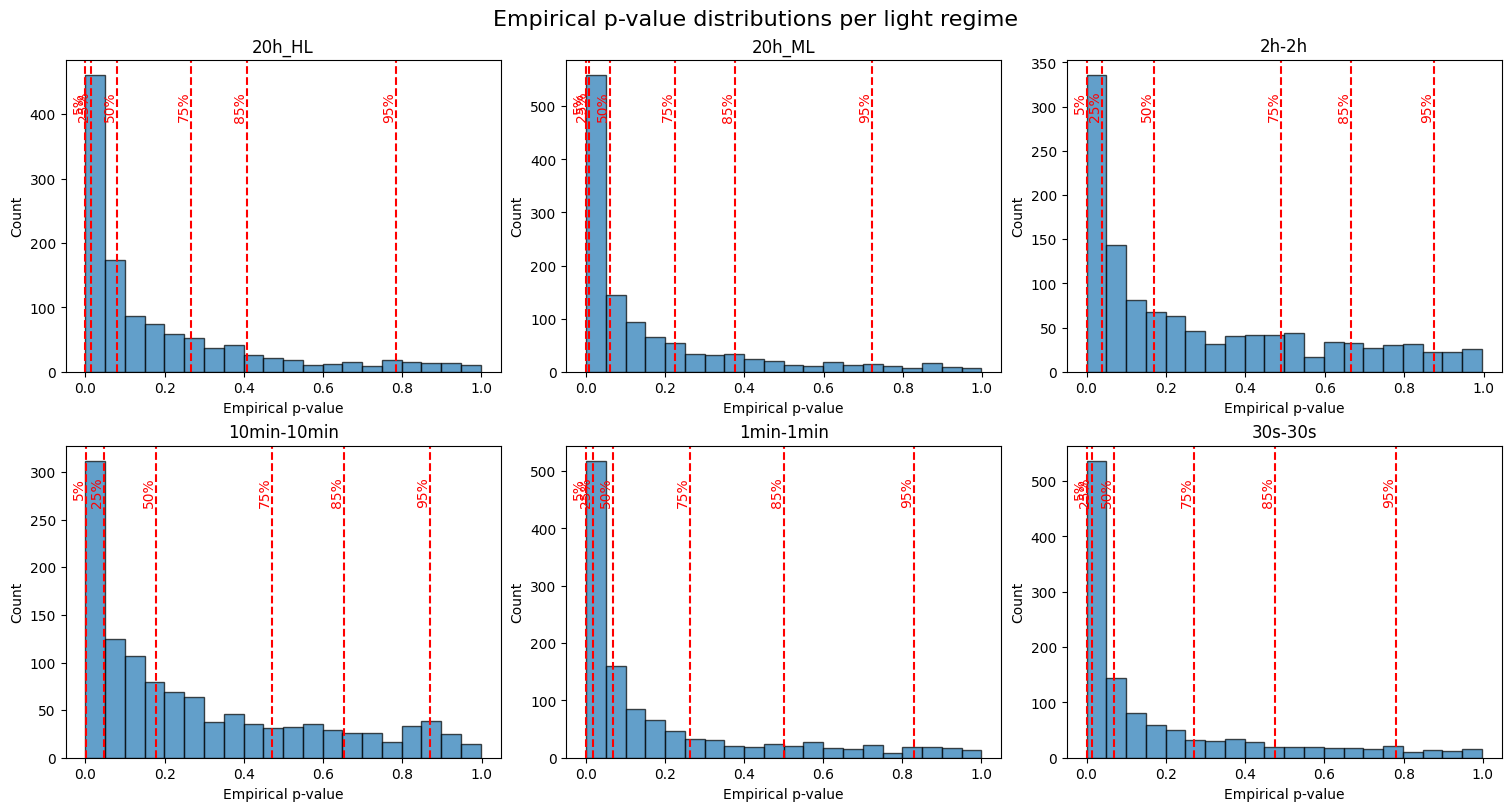

In [18]:
empirical_pvals_df = t_test_results
import numpy as np

light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '1min-1min', '30s-30s']
n = len(light_regimes)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4), constrained_layout=True)
axes = axes.flatten()

for i, light in enumerate(light_regimes):
    ax = axes[i]
    pvals = empirical_pvals_df[empirical_pvals_df['light_regime'] == light]['p_value'].dropna()

    ax.hist(pvals, bins=20, edgecolor='black', alpha=0.7)
    ax.set_title(light)
    ax.set_xlabel('Empirical p-value')
    ax.set_ylabel('Count')

    for q in [5, 25, 50, 75, 85, 95]:
        perc = np.percentile(pvals, q)
        ax.axvline(perc, color='red', linestyle='--')
        ax.text(perc, ax.get_ylim()[1]*0.9, f'{q}%', rotation=90, color='red', va='top', ha='right')

# Supprimer les cases vides si le nombre de régimes est < 9
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Empirical p-value distributions per light regime', fontsize=16)
plt.show()


### Y2 TS plots

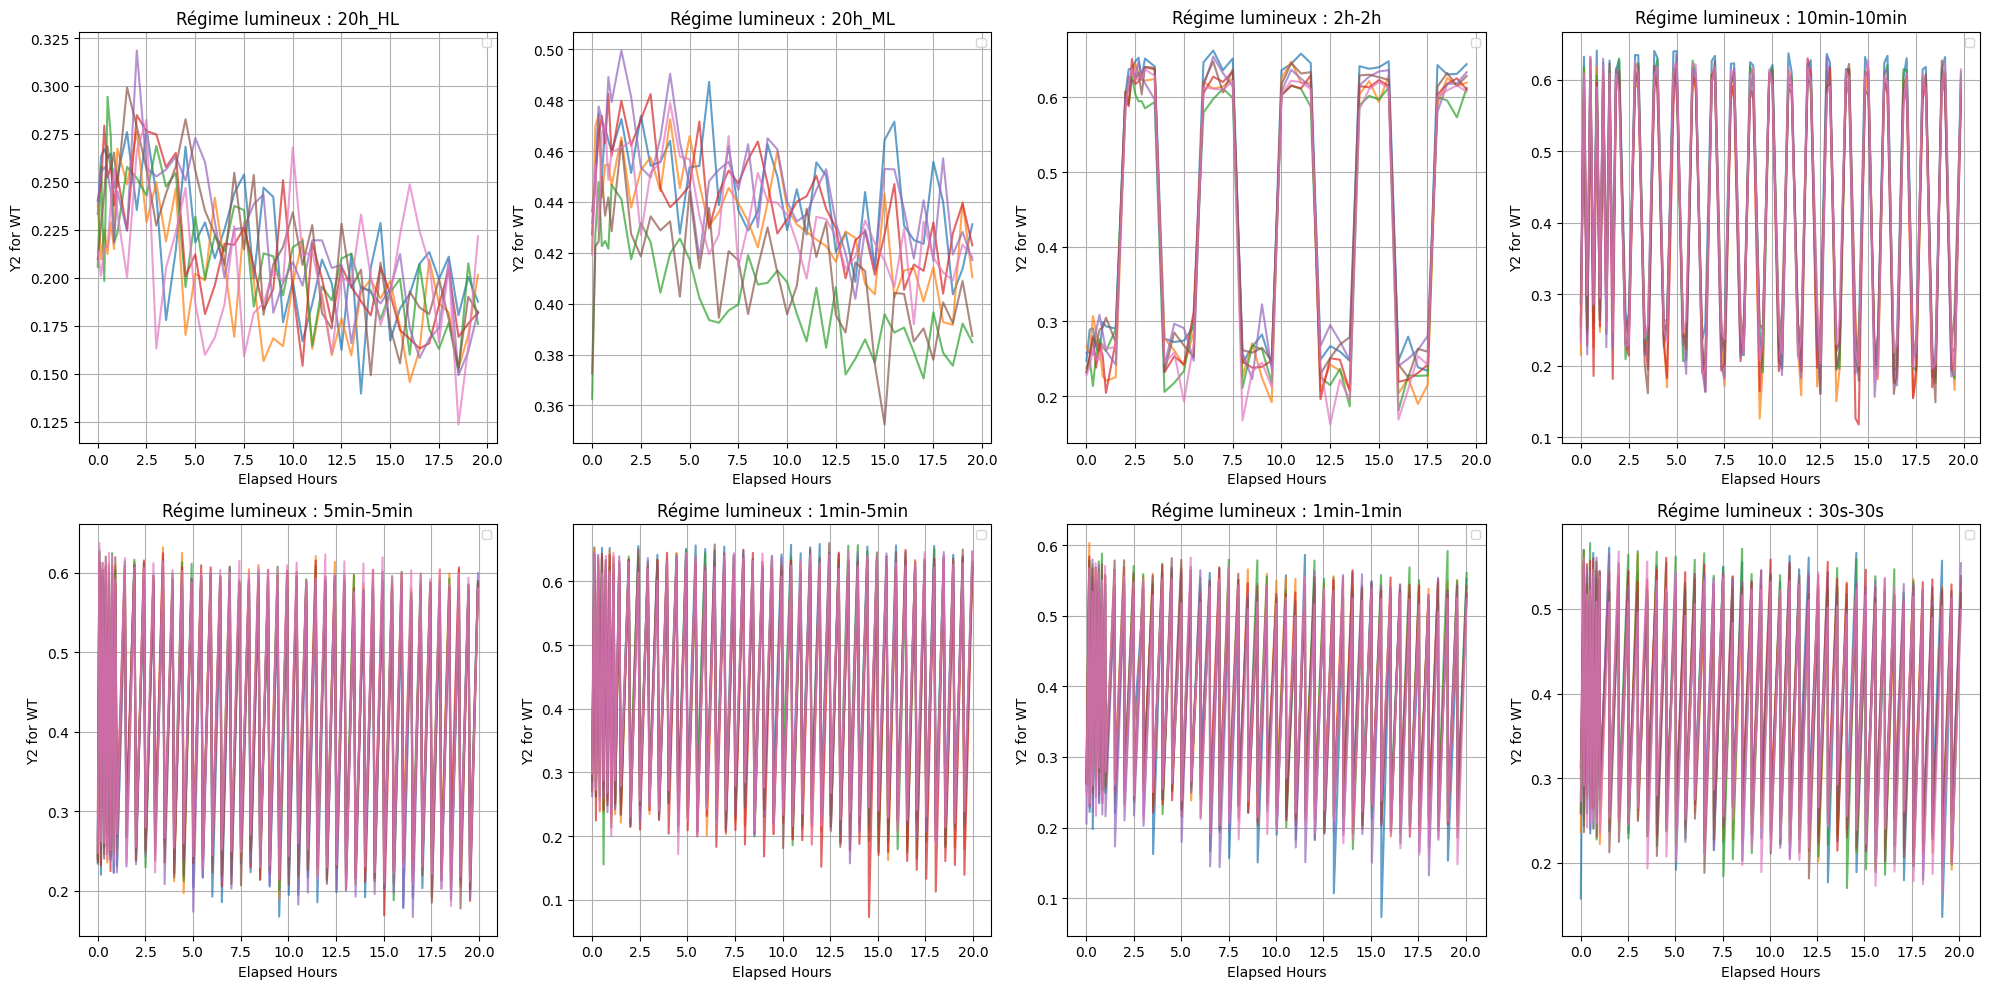

In [15]:
import pandas as pd
data = pd.read_csv('/Users/imanemokhtatif/Desktop/REMOTEChlamy_Project_v2-main/Data/2025_5_phase2.csv')
data = data[data['plate']=='33v1']
y2_columns = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col]


# for processed data (elapsed_hours cols added)
elapsed_hours = [col for col in data.columns if col.startswith('elapsed_hours_')]
elapsed_hours = data[elapsed_hours]

# for raw data
# time_columns = [col for col in data.columns if col.startswith('measurement_time_')]
# for col in time_columns:
#     data[col] = pd.to_datetime(data[col],format='mixed')
# elapsed_hours = data[time_columns].apply(lambda row: (row - row.min()).dt.total_seconds() / 3600, axis=1)
# elapsed_hours.columns = [f'elapsed_hours_{i}' for i in range(len(elapsed_hours.columns))]
# data = pd.concat([data, elapsed_hours], axis=1)

light_regimes = [
    '20h_HL', '20h_ML', '2h-2h', '10min-10min',
    '5min-5min', '1min-5min', '1min-1min', '30s-30s'
]

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10)) 
axes = axes.flatten()
for i, light in enumerate(light_regimes):
    ax = axes[i] 
    data_light = data[(data['light_regime'] == light)]# & (data['plate'].astype(str).str.startswith('33'))]
    for plate in data_light['plate'].unique():
        data_plate = data_light[(data_light['mutant_ID'].isin(['WT', 'WT CLiP'])) & (data_light['plate'] == plate)]
        for _, row in data_plate.iterrows():
            y2_values = row[y2_columns].values
            time_values = row[elapsed_hours.columns].astype(float).values

            valid_indices = ~np.isnan(time_values)
            time_values = time_values[valid_indices]
            y2_values = y2_values[:len(time_values)]  
            time_values = time_values[:len(y2_values)]
            ax.plot(time_values, y2_values, alpha=0.7)#, label=f'Plate {plate}')
    #axes[i].set_xlim(0, 5)
    ax.set_title(f'Régime lumineux : {light}')
    ax.set_xlabel('Elapsed Hours')
    ax.set_ylabel('Y2 for WT')
    ax.grid(True)
    ax.legend(fontsize='small', loc='upper right')
for j in range(len(light_regimes), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

In [47]:
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase2_05_RAWslopes.csv')
data = data[data['plate'].astype(str).str.startswith('32v2')]
data['light_regime'].unique()

array(['1min-1min', '20h_HL', '20h_ML', '2h-2h', '30s-30s', '10min-10min',
       '1min-5min', '5min-5min'], dtype=object)

## BOX PLOTS

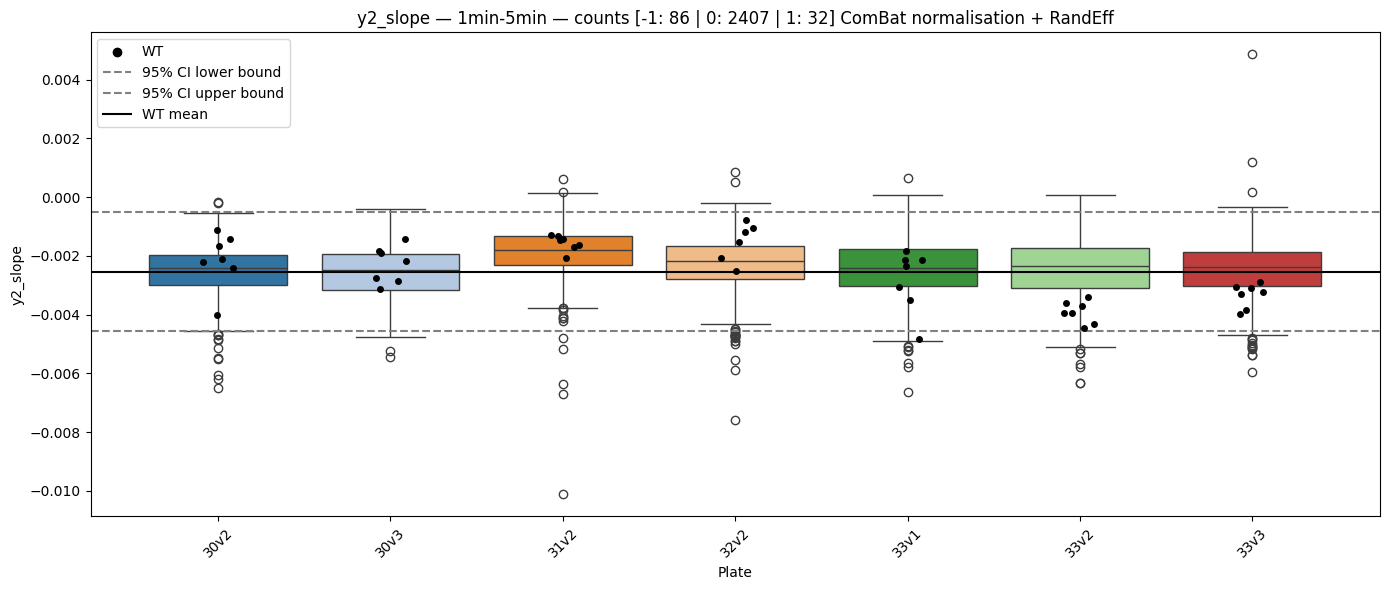

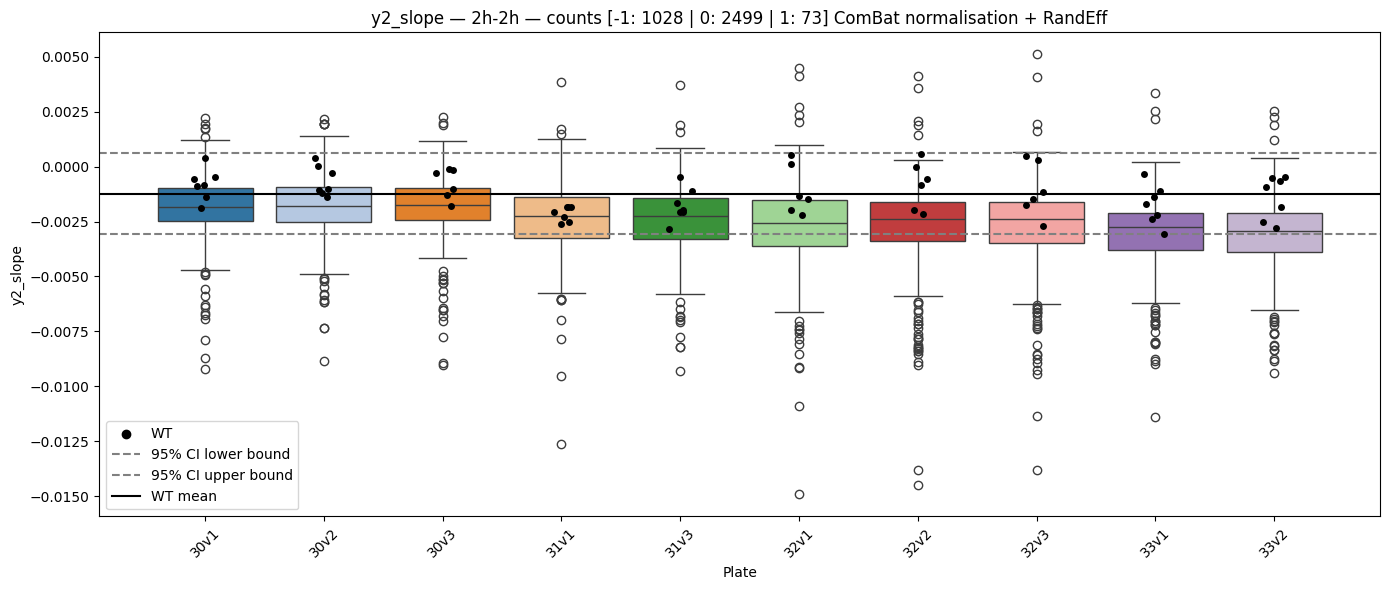

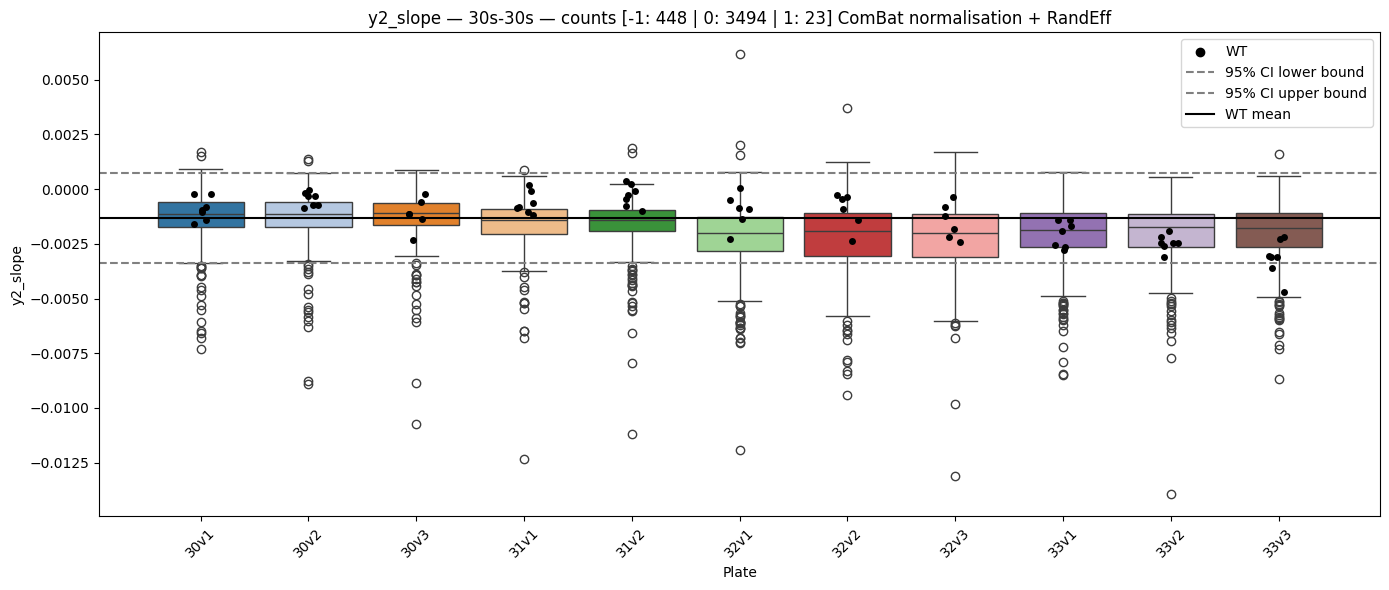

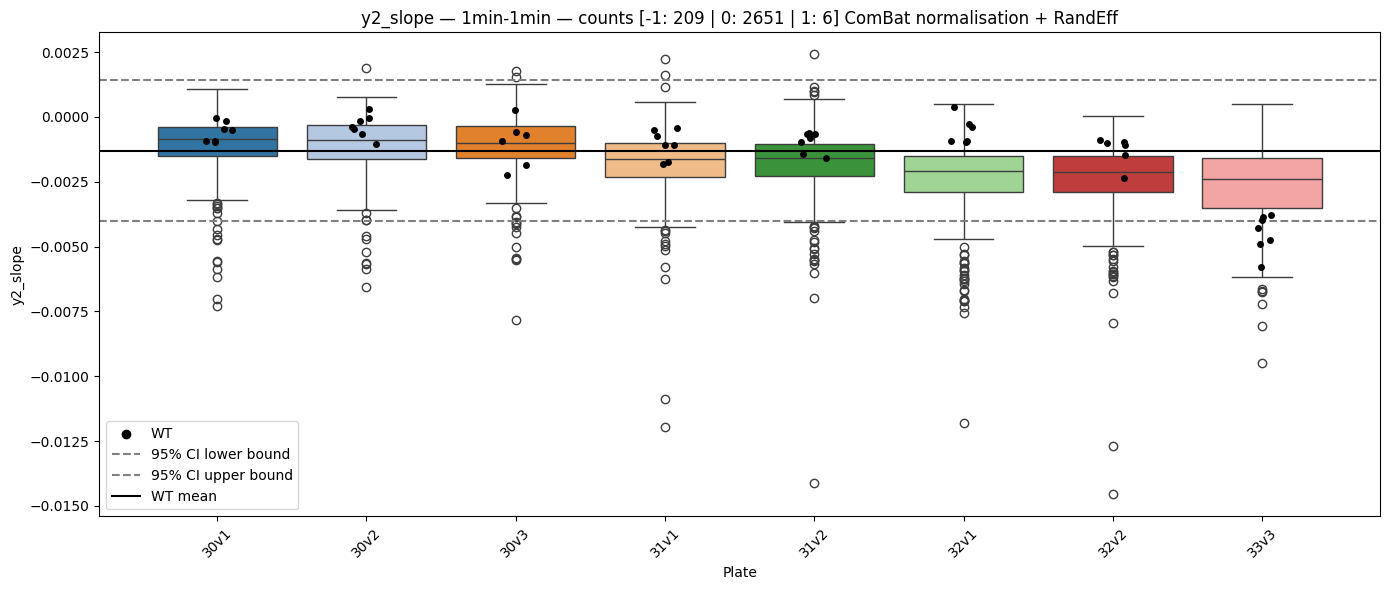

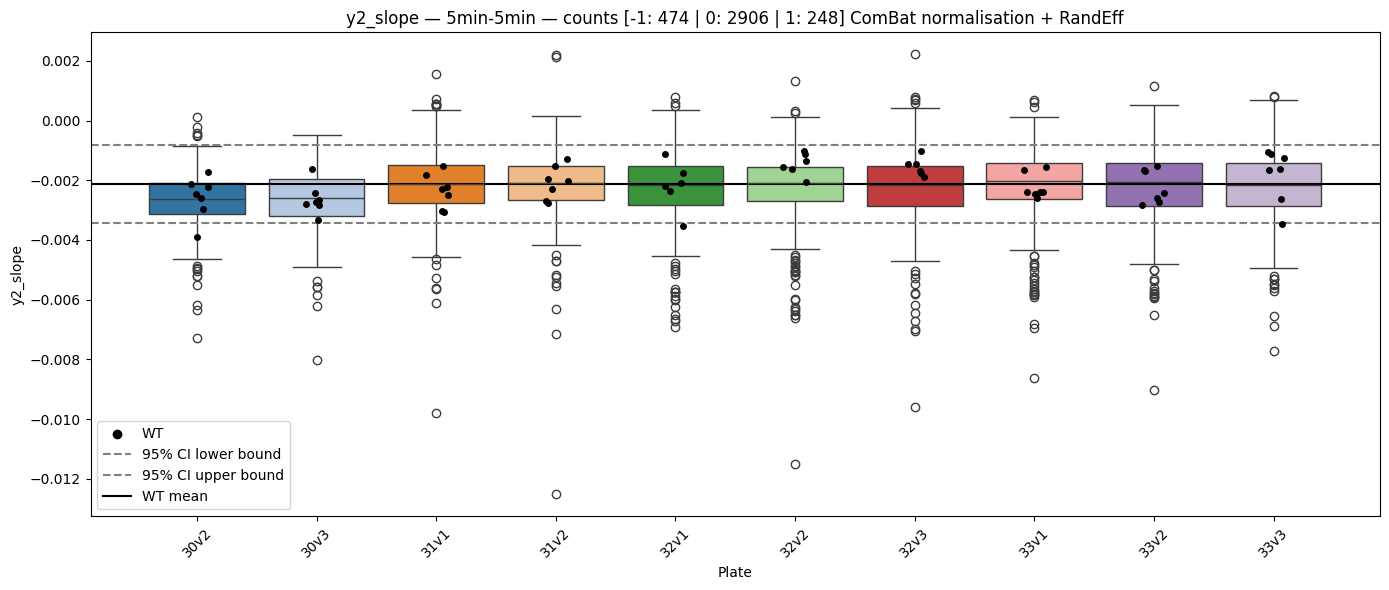

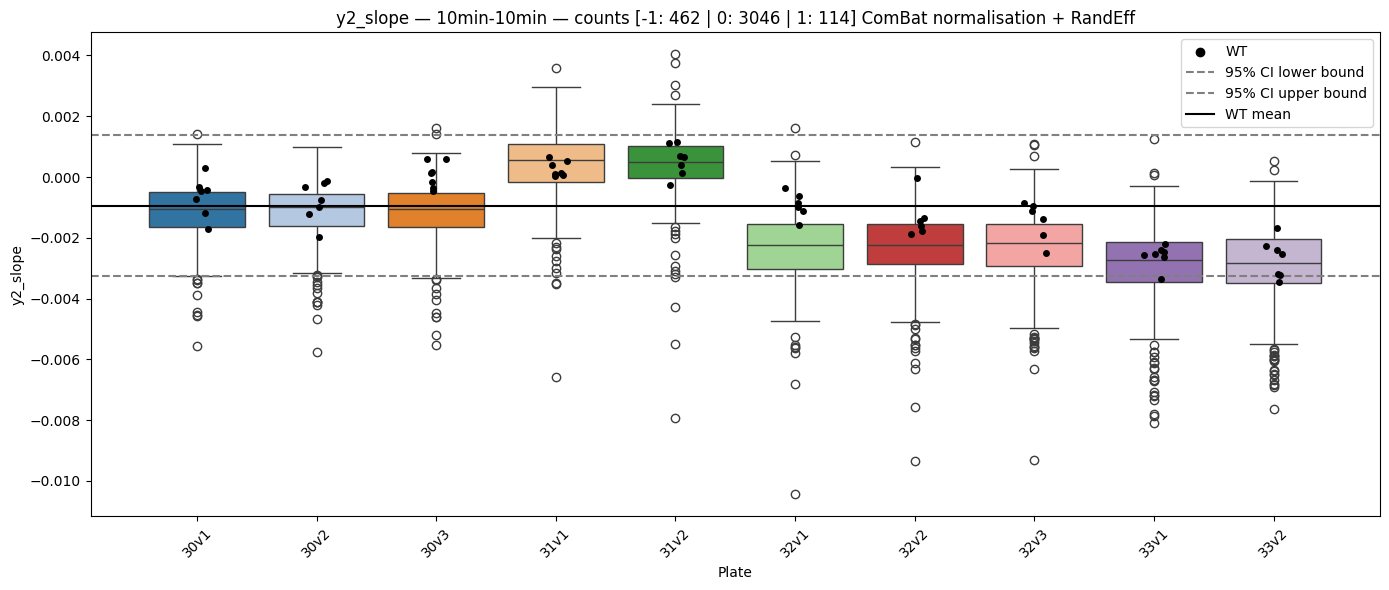

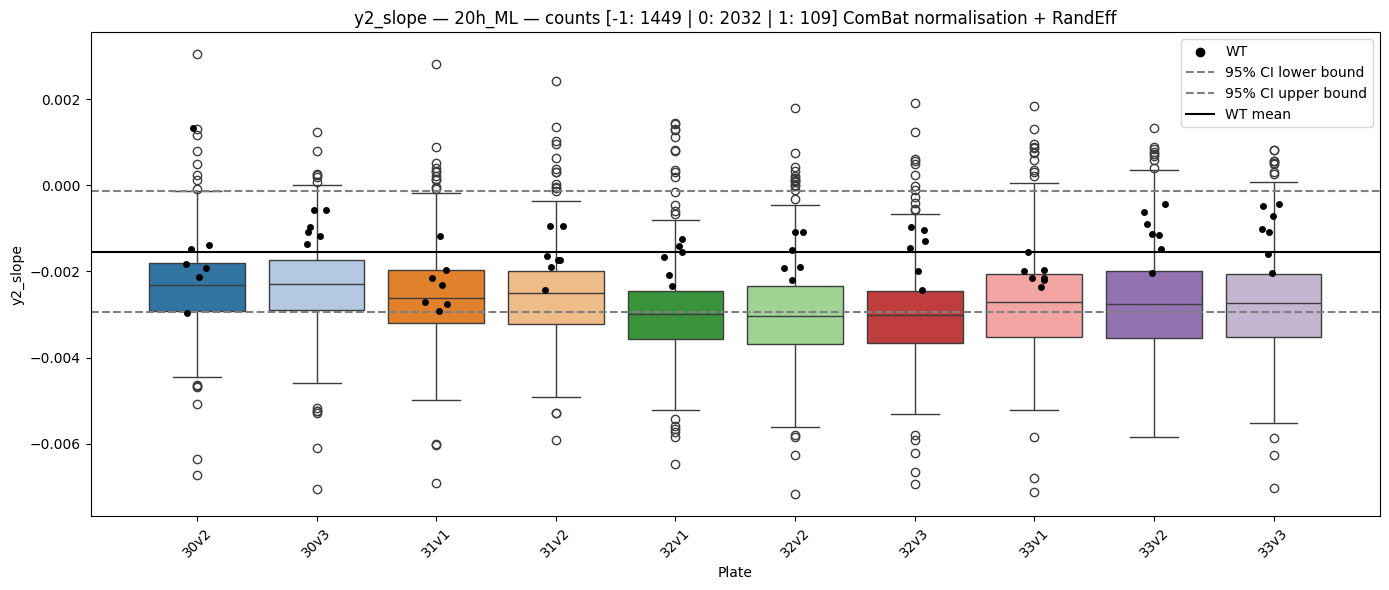

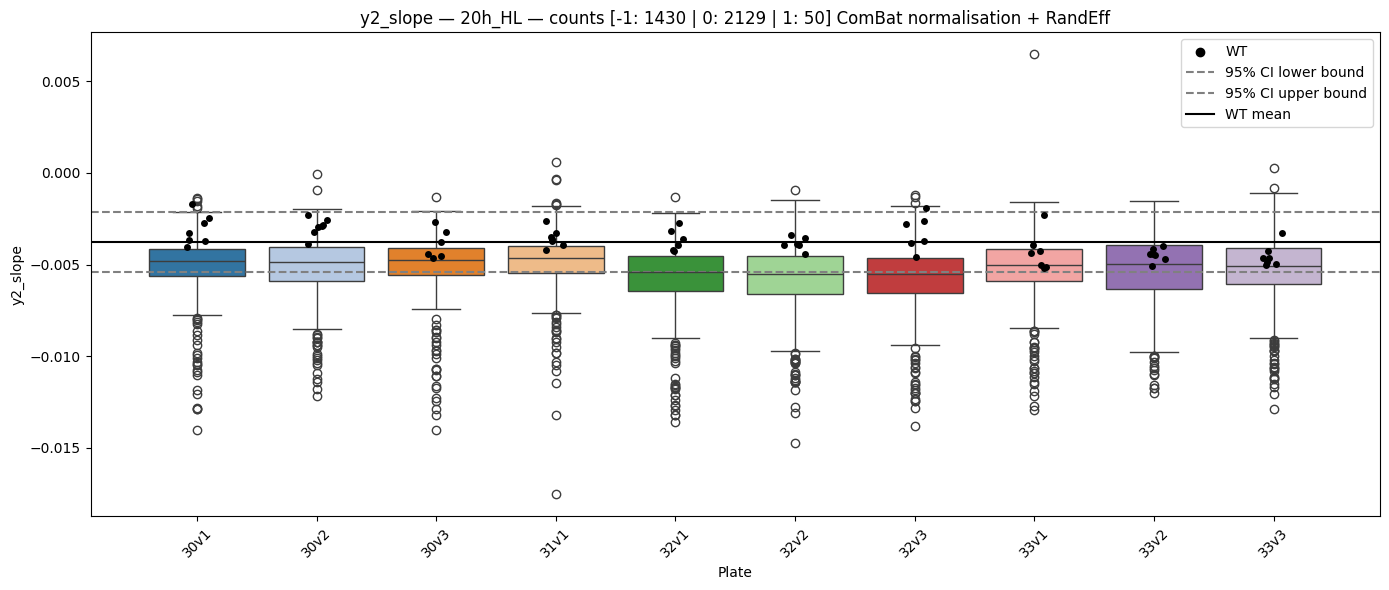

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def detect_and_plot_slope_outliers(data, alpha=0.05, plot=True):
    data_cluster = pd.DataFrame()

    for light in data['light_regime'].unique():
        data_light = data[data['light_regime'] == light].reset_index(drop=True)
        wt_mask = data_light['mutant_ID'].isin(['WT', 'WT CLiP'])
        mutant_mask = ~wt_mask

        wt_slopes = data_light[wt_mask]['y2_slope'].dropna().values
        if len(wt_slopes) < 2:
            continue

        mu, sigma = norm.fit(wt_slopes)
        ci_low, ci_high = norm.interval(1 - alpha, loc=mu, scale=sigma)

        data_light['slope_cluster_y2'] = 0
        data_light['y2_deviation'] = 0.0

        for idx in data_light.index:
            slope = data_light.loc[idx, 'y2_slope']
            if not np.isfinite(slope):
                continue
            if slope < ci_low:
                data_light.loc[idx, 'slope_cluster_y2'] = -1
                data_light.loc[idx, 'y2_deviation'] = ci_low - slope
            elif slope > ci_high:
                data_light.loc[idx, 'slope_cluster_y2'] = 1
                data_light.loc[idx, 'y2_deviation'] = slope - ci_high

        data_cluster = pd.concat([data_cluster, data_light])

        if plot:
            to_plot_wt = data_light[wt_mask].copy()
            to_plot_mutants = data_light[mutant_mask].copy()

            to_plot_wt['plate'] = to_plot_wt['plate'].astype(str)
            to_plot_mutants['plate'] = to_plot_mutants['plate'].astype(str)
            ordered_plates = sorted(data_light['plate'].unique())

            plt.figure(figsize=(14, 6))
            sns.boxplot(data=to_plot_mutants, x='plate', y='y2_slope', palette="tab20", order=ordered_plates)
            sns.stripplot(data=to_plot_wt, x='plate', y='y2_slope', color='black', size=5, jitter=True, order=ordered_plates)
            plt.scatter([], [], color='black', label='WT')
            plt.axhline(ci_low, color='gray', linestyle='--', label='95% CI lower bound')
            plt.axhline(ci_high, color='gray', linestyle='--', label='95% CI upper bound')
            plt.axhline(mu, color='black', linestyle='-', label='WT mean')

            count_str = " | ".join([f"{k}: {to_plot_mutants['slope_cluster_y2'].tolist().count(k)}" for k in [-1, 0, 1]])
            plt.title(f'y2_slope — {light} — counts [{count_str}] ComBat normalisation + RandEff')
            plt.ylabel('y2_slope')
            plt.xlabel('Plate')
            #plt.ylim(-0.005, 0.003)
            plt.xticks(rotation=45)
            plt.legend()
            plt.tight_layout()
            plt.show()


# Exemple d'appel
data=pd.read_csv('/Users/imanemokhtatif/Desktop/REMOTEChlamy_Project_v2-main/Data/2025_5_phase2_light_status_slope_COMBATT_randeffONLYPLATES.csv')
data = data[data['plate'].astype(str).str.startswith('3')]#data['plate'] = data['plate'].astype(str)
#data['y2_slope'] = data['y2_slope_mixed_centered']

detect_and_plot_slope_outliers(data, alpha=0.05, plot=True)


In [54]:
for e in data['mutant_ID'].unique():
    print(e, len(data['mutated_genes'].unique()))

LMJ.RY0402.038871 171
LMJ.RY0402.039259 171
LMJ.RY0402.040675 171
LMJ.RY0402.041124 171
LMJ.RY0402.041401 171
LMJ.RY0402.041908 171
LMJ.RY0402.042123 171
LMJ.RY0402.042144 171
LMJ.RY0402.042891 171
LMJ.RY0402.043444 171
LMJ.RY0402.043448 171
LMJ.RY0402.043847 171
LMJ.RY0402.044293 171
LMJ.RY0402.045771 171
LMJ.RY0402.045852 171
LMJ.RY0402.046330 171
LMJ.RY0402.046521 171
LMJ.RY0402.046990 171
LMJ.RY0402.047311 171
LMJ.RY0402.047320 171
LMJ.RY0402.047723 171
LMJ.RY0402.049720 171
LMJ.RY0402.049779 171
LMJ.RY0402.050380 171
LMJ.RY0402.051183 171
LMJ.RY0402.051400 171
LMJ.RY0402.051591 171
LMJ.RY0402.052440 171
LMJ.RY0402.054597 171
LMJ.RY0402.054897 171
LMJ.RY0402.056549 171
LMJ.RY0402.056638 171
LMJ.RY0402.056862 171
LMJ.RY0402.057337 171
LMJ.RY0402.057984 171
LMJ.RY0402.058246 171
LMJ.RY0402.059212 171
LMJ.RY0402.059521 171
LMJ.RY0402.060051 171
LMJ.RY0402.061062 171
LMJ.RY0402.061332 171
LMJ.RY0402.061371 171
LMJ.RY0402.061417 171
LMJ.RY0402.061906 171
LMJ.RY0402.062549 171
LMJ.RY0402